In [2]:
# Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Исправление стиля: 'seaborn' больше не работает как plt.style.use
# Вместо этого используем 'seaborn-v0_8' или просто включаем seaborn
plt.style.use('default')  # Базовый стиль
sns.set_style("whitegrid")  # Стиль от seaborn
sns.set_palette("husl")

# Проверка версии
print(f"TensorFlow версия: {tf.__version__}")

TensorFlow версия: 2.20.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 31s 3us/step
Обучающая выборка: (60000, 28, 28), метки: (60000,)
Тестовая выборка: (10000, 28, 28), метки: (10000,)


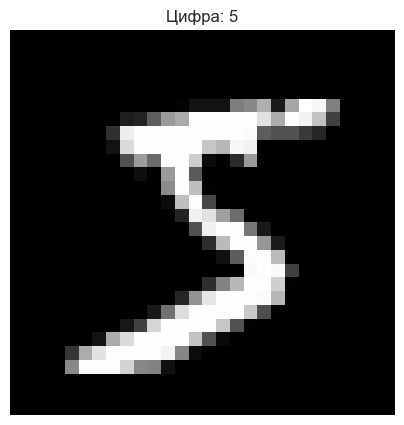

In [3]:
# Загрузка датасета MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Вывод размеров данных
print(f"Обучающая выборка: {x_train.shape}, метки: {y_train.shape}")
print(f"Тестовая выборка: {x_test.shape}, метки: {y_test.shape}")

# Пример одного изображения
plt.figure(figsize=(5,5))
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Цифра: {y_train[0]}")
plt.axis('off')
plt.show()

In [4]:
# Нормализация пикселей: [0, 255] → [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Добавляем размерность канала (для CNN): (28, 28) → (28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot кодирование меток (10 классов)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"После one-hot: {y_train_cat.shape}")

После one-hot: (60000, 10)


In [5]:
# Создание модели
model = keras.Sequential([
    # Свёрточный блок 1
    layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(pool_size=(2,2)),
    
    # Свёрточный блок 2
    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),
    
    # Выравнивание и полносвязные слои
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 классов
])

# Вывод архитектуры
model.summary()

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Компиляция модели
model.compile(
    optimizer='adam',                    # Адаптивный оптимизатор
    loss='categorical_crossentropy',     # Для многоклассовой классификации
    metrics=['accuracy']                 # Метрика точности
)

print("Модель успешно скомпилирована!")

Модель успешно скомпилирована!


In [7]:
# Обучение модели
history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=15,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.9428 - loss: 0.1969 - val_accuracy: 0.9813 - val_loss: 0.0589
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9828 - loss: 0.0566 - val_accuracy: 0.9847 - val_loss: 0.0443
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9873 - loss: 0.0400 - val_accuracy: 0.9897 - val_loss: 0.0303
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.9900 - loss: 0.0304 - val_accuracy: 0.9875 - val_loss: 0.0360
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9926 - loss: 0.0226 - val_accuracy: 0.9898 - val_loss: 0.0303
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9942 - loss: 0.0185 - val_accuracy: 0.9884 - val_loss: 0.0362
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9948 - loss: 0.0156 - val_accuracy: 0.9871 - val_loss: 0.0379
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9958 - loss: 0.0119 - 

Тестовая точность: 0.9885, Потери: 0.0470


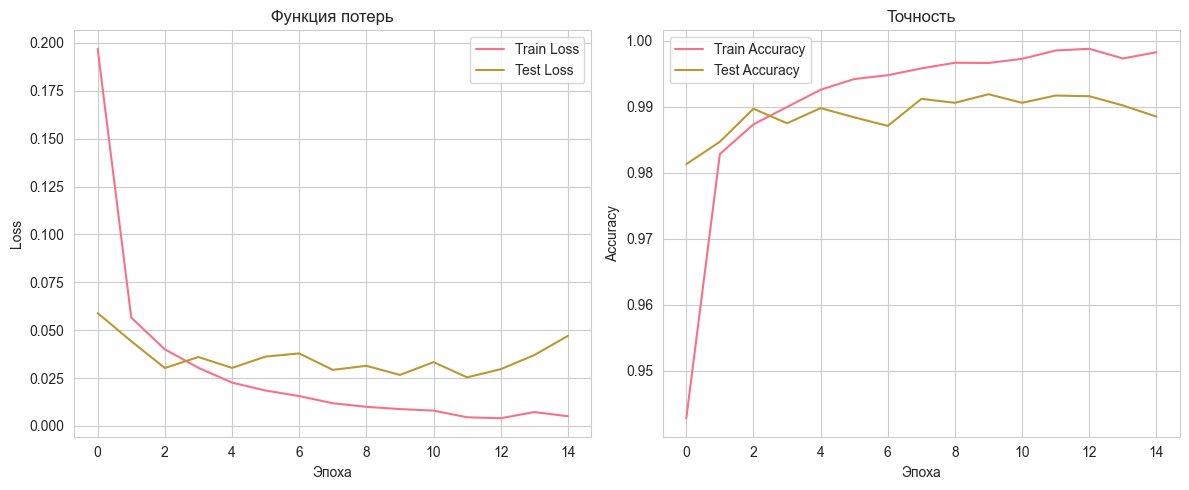

In [8]:
# Оценка на тестовых данных
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Тестовая точность: {test_acc:.4f}, Потери: {test_loss:.4f}")

# Графики функции потерь и точности
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Точность')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Проверяем разницу между train и val accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
print(f"Train acc: {train_acc:.4f}, Val acc: {val_acc:.4f}")
print(f"Разница: {train_acc - val_acc:.4f}")

# Если разница > 0.05 — возможно переобучение

Train acc: 0.9983, Val acc: 0.9885
Разница: 0.0098


In [10]:
# Новая модель с Dropout
model_dropout = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Отключаем 50% нейронов
    layers.Dense(10, activation='softmax')
])

model_dropout.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# Обучение
history_dropout = model_dropout.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=15,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9094 - loss: 0.2958 - val_accuracy: 0.9824 - val_loss: 0.0587
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.9718 - loss: 0.0939 - val_accuracy: 0.9847 - val_loss: 0.0429
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9786 - loss: 0.0714 - val_accuracy: 0.9896 - val_loss: 0.0333
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9830 - loss: 0.0564 - val_accuracy: 0.9882 - val_loss: 0.0342
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9852 - loss: 0.0497 - val_accuracy: 0.9906 - val_loss: 0.0270
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9871 - loss: 0.0432 - val_accuracy: 0.9910 - val_loss: 0.0284
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.9876 - loss: 0.0385 - val_accuracy: 0.9920 - val_loss: 0.0235
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9900 - loss: 0.0330 - 

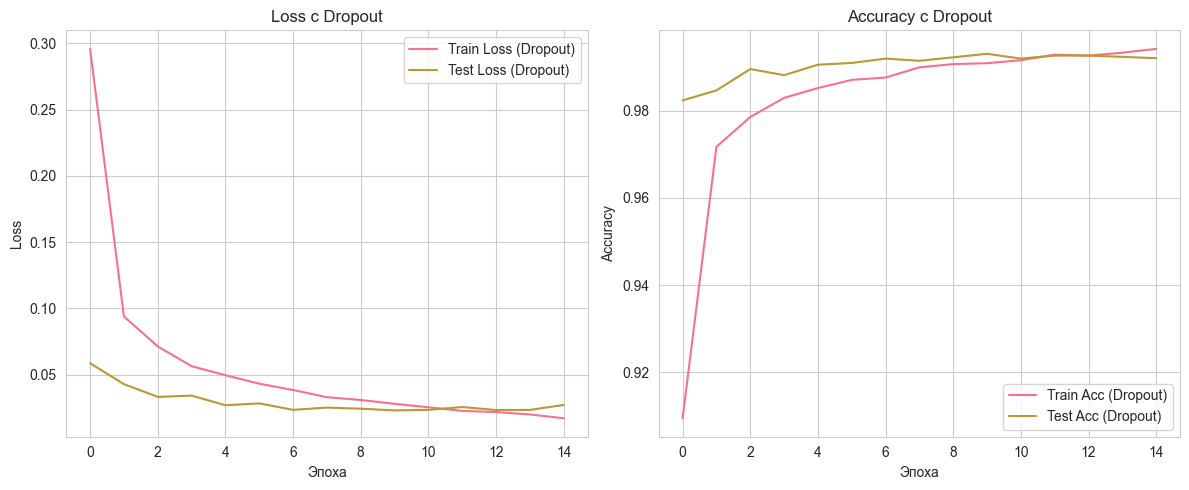

Тестовая точность с Dropout: 0.9921


In [11]:
# Графики для модели с Dropout
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['loss'], label='Train Loss (Dropout)')
plt.plot(history_dropout.history['val_loss'], label='Test Loss (Dropout)')
plt.title('Loss с Dropout')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['accuracy'], label='Train Acc (Dropout)')
plt.plot(history_dropout.history['val_accuracy'], label='Test Acc (Dropout)')
plt.title('Accuracy с Dropout')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Финальная точность
test_loss_d, test_acc_d = model_dropout.evaluate(x_test, y_test_cat, verbose=0)
print(f"Тестовая точность с Dropout: {test_acc_d:.4f}")

In [12]:
# Подготовка данных для полносвязной сети (flatten)
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

# Простая полносвязная сеть
model_mlp = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model_mlp.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_mlp = model_mlp.fit(
    x_train_flat, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_data=(x_test_flat, y_test_cat),
    verbose=1
)

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - accuracy: 0.9108 - loss: 0.2968 - val_accuracy: 0.9657 - val_loss: 0.1116
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9617 - loss: 0.1234 - val_accuracy: 0.9729 - val_loss: 0.0854
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9721 - loss: 0.0902 - val_accuracy: 0.9769 - val_loss: 0.0759
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9770 - loss: 0.0742 - val_accuracy: 0.9766 - val_loss: 0.0775
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9810 - loss: 0.0596 - val_accuracy: 0.9787 - val_loss: 0.0665
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9828 - loss: 0.0527 - val_accuracy: 0.9822 - val_loss: 0.0578
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9851 - loss: 0.0482 - val_accuracy: 0.9800 - val_loss: 0.0697
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9857 - loss: 0.0437 - 

In [13]:
# Сравнение точности
_, acc_cnn = model.evaluate(x_test, y_test_cat, verbose=0)
_, acc_dropout = model_dropout.evaluate(x_test, y_test_cat, verbose=0)
_, acc_mlp = model_mlp.evaluate(x_test_flat, y_test_cat, verbose=0)

print("=== Сравнение моделей ===")
print(f"CNN (без Dropout):     {acc_cnn:.4f}")
print(f"CNN + Dropout:         {acc_dropout:.4f}")
print(f"MLP (полносвязная):    {acc_mlp:.4f}")

=== Сравнение моделей ===
CNN (без Dropout):     0.9885
CNN + Dropout:         0.9921
MLP (полносвязная):    0.9815


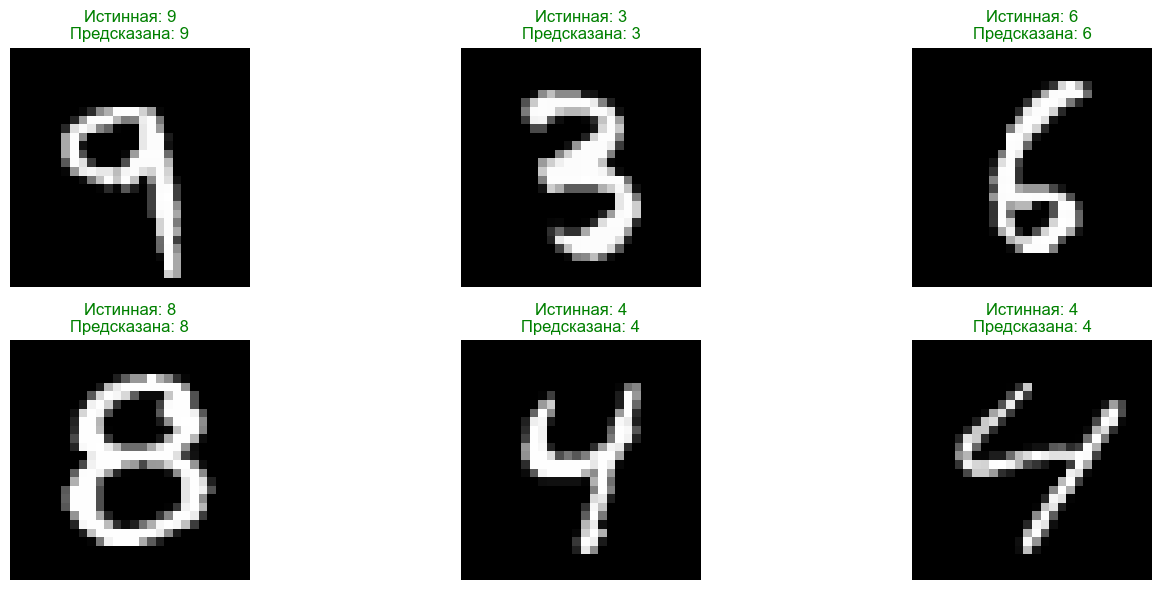

In [14]:
# Блок для добавления в конец
import numpy as np

# Предсказание на 6 случайных изображениях
indices = np.random.randint(0, len(x_test), 6)
plt.figure(figsize=(15, 6))

for i, idx in enumerate(indices):
    pred = model_dropout.predict(x_test[idx:idx+1], verbose=0)
    pred_label = np.argmax(pred)
    true_label = y_test[idx]
    
    plt.subplot(2, 3, i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Истинная: {true_label}\nПредсказана: {pred_label}", 
              color='green' if pred_label == true_label else 'red')
    plt.axis('off')

plt.tight_layout()
plt.show()